# Project 5B: Flow Matching from Scratch!
<p style="color: red;"><strong>Note:</strong> You are not required to use the exact .ipynb notebook
         +or format (e.g., you can use a .py or modify the .ipynb however you wish). We only need to see the required deliverables / visualizations.</p>

## Setup environment

In [2]:
# We recommend using these utils.
# https://google.github.io/mediapy/mediapy.html
# https://einops.rocks/
!pip install mediapy einops --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 24.3 MB/s eta 0:00:00


In [3]:
# Import essential modules.
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor
from tqdm import tqdm
import mediapy as media
import os

## Neural Network Resources

In this part, you will build and train a [UNet](https://arxiv.org/abs/1505.04597), which is more complex than the MLP you implemented in the NeRF project.  We provide all class definitions you may need (but feel free to add or modify them as necessary).  

Instead of asking ChatGPT to write everything for you, please consult the following resources when you get stuck — they will help you understand how and why things work under the hood.

- PyTorch Documentation — [`Conv2d`](https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html), [`ConvTranspose2d`](https://docs.pytorch.org/docs/stable/generated/torch.nn.ConvTranspose2d.html), and [`AvgPool2d`](https://docs.pytorch.org/docs/stable/generated/torch.nn.AvgPool2d.html).
- PyTorch Documentation - [`torchvision.datasets.MNIST`](https://docs.pytorch.org/vision/main/generated/torchvision.datasets.MNIST.html), the dataset we gonna use, and [`torch.utils.data.DataLoader`](https://docs.pytorch.org/docs/stable/data.html), the off-the-shell dataloader we can directly use.
- PyTorch [tutorial](https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html) on how to train a classifier on CIFAR10 dataset. The structure of your training code will be very similar to this one.

# Part 1: Training a Single-step Denoising UNet


# Part 1.1: Implementing the UNet

## Implementing Simple and Composed Ops

In [4]:
class Conv(nn.Module):
    """Conv2d(3,1,1) -> BN -> GELU. Maintains spatial dims, changes channels."""
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        # ===== your code here! ====
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.GELU(),
        )
        # ===== end of code ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ===== your code here! ====
        return self.net(x)
        # ===== end of code ====
        raise NotImplementedError()


class DownConv(nn.Module):
    """Conv2d(3,2,1) -> BN -> GELU. Downsamples spatial dims by 2."""
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        # ===== your code here! ====
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.GELU(),
        )
        # ===== end of code ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ===== your code here! ====
        return self.net(x)
        # ===== end of code ====
        raise NotImplementedError()


class UpConv(nn.Module):
    """ConvTranspose2d(4,2,1) -> BN -> GELU. Upsamples spatial dims by 2."""
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        # ===== your code here! ====
        self.net = nn.Sequential(
            nn.ConvTranspose2d(in_channels, out_channels, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.GELU(),
        )
        # ===== end of code ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ===== your code here! ====
        return self.net(x)
        # ===== end of code ====
        raise NotImplementedError()


class Flatten(nn.Module):
    """AvgPool2d(7) -> BN -> GELU. Flattens 7x7 to 1x1."""
    def __init__(self):
        super().__init__()
        # ===== your code here! ====
        # AvgPool with kernel_size=7 collapses 7x7 -> 1x1
        self.pool = nn.AvgPool2d(kernel_size=7)
        # ===== end of code ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ===== your code here! ====
        return self.pool(x)
        # ===== end of code ====
        raise NotImplementedError()


class Unflatten(nn.Module):
    """ConvTranspose2d(7,1,0) -> BN -> GELU. Unflattens 1x1 to 7x7."""
    def __init__(self, in_channels: int):
        super().__init__()
        # ===== your code here! ====
        self.net = nn.Sequential(
            nn.ConvTranspose2d(in_channels, in_channels, kernel_size=7, stride=1, padding=0),
            nn.BatchNorm2d(in_channels),
            nn.GELU(),
        )
        # ===== end of code ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ===== your code here! ====
        return self.net(x)
        # ===== end of code ====
        raise NotImplementedError()


class ConvBlock(nn.Module):
    """Conv -> Conv. Maintains spatial dims and channels (goes through out_channels internally)."""
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        # ===== your code here! ====
        self.net = nn.Sequential(
            Conv(in_channels, out_channels),
            Conv(out_channels, out_channels),
        )
        # ===== end of code ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ===== your code here! ====
        return self.net(x)
        # ===== end of code ====
        raise NotImplementedError()


class DownBlock(nn.Module):
    """ConvBlock -> DownConv. Downsamples by 2."""
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        # ===== your code here! ====
        self.conv_block = ConvBlock(in_channels, in_channels)
        self.down = DownConv(in_channels, out_channels)
        # ===== end of code ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ===== your code here! ====
        return self.down(self.conv_block(x))
        # ===== end of code ====
        raise NotImplementedError()


class UpBlock(nn.Module):
    """UpConv -> ConvBlock. Upsamples by 2."""
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        # ===== your code here! ====
        self.up = UpConv(in_channels, out_channels)
        self.conv_block = ConvBlock(out_channels, out_channels)
        # ===== end of code ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ===== your code here! ====
        return self.conv_block(self.up(x))
        # ===== end of code ====
        raise NotImplementedError()

## Implementing Unconditional UNet

In [5]:
class UnconditionalUNet(nn.Module):
    """
    UNet for single-step denoising (no time/class conditioning).

    Architecture (from assignment diagram):
    Input: (N, 1, 28, 28)

    Encoder:
      conv_in:  Conv  1 -> D          (28x28)
      down1:    DownBlock D -> 2D      (14x14)
      down2:    DownBlock 2D -> 4D     (7x7)
      flatten:  Flatten               (1x1)

    Bottleneck:
      unflatten: Unflatten            (7x7)

    Decoder (with skip connections via concat):
      up1:   UpBlock 4D+4D -> 2D      (14x14)
      up2:   UpBlock 2D+2D -> D       (28x28)
      conv_out: Conv D+D -> 1         (28x28)
    """
    def __init__(
        self,
        in_channels: int,
        num_hiddens: int,
    ):
        super().__init__()
        # ===== your code here! ====
        D = num_hiddens

        # Encoder
        self.conv_in = ConvBlock(in_channels, D)      # 28x28, D channels
        self.down1 = DownBlock(D, 2 * D)              # 14x14, 2D channels
        self.down2 = DownBlock(2 * D, 4 * D)          # 7x7,   4D channels
        self.flatten = Flatten()                       # 1x1,   4D channels

        # Bottleneck
        self.unflatten = Unflatten(4 * D)              # 7x7,   4D channels

        # Decoder (skip connections double input channels)
        self.up1 = UpBlock(4 * D + 4 * D, 2 * D)     # 14x14, 2D channels
        self.up2 = UpBlock(2 * D + 2 * D, D)          # 28x28, D channels
        self.conv_out = nn.Conv2d(D + D, in_channels, kernel_size=1)  # final 1x1 conv
        # ===== end of code ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        assert x.shape[-2:] == (28, 28), "Expect input shape to be (28, 28)."
        # ===== your code here! ====

        # Encoder
        x0 = self.conv_in(x)     # (N, D, 28, 28)
        x1 = self.down1(x0)      # (N, 2D, 14, 14)
        x2 = self.down2(x1)      # (N, 4D, 7, 7)
        xf = self.flatten(x2)    # (N, 4D, 1, 1)

        # Bottleneck
        xu = self.unflatten(xf)  # (N, 4D, 7, 7)

        # Decoder with skip connections
        xu = self.up1(torch.cat([xu, x2], dim=1))   # concat -> (N, 8D, 7, 7) -> up -> (N, 2D, 14, 14)
        xu = self.up2(torch.cat([xu, x1], dim=1))   # concat -> (N, 4D, 14, 14) -> up -> (N, D, 28, 28)
        xu = self.conv_out(torch.cat([xu, x0], dim=1))  # concat -> (N, 2D, 28, 28) -> (N, 1, 28, 28)
        return xu
        # ===== end of code ====
        raise NotImplementedError()

# Part 1.2: Using the UNet to Train a Denoiser

100%|██████████| 9.91M/9.91M [00:00<00:00, 54.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.67MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.5MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.74MB/s]


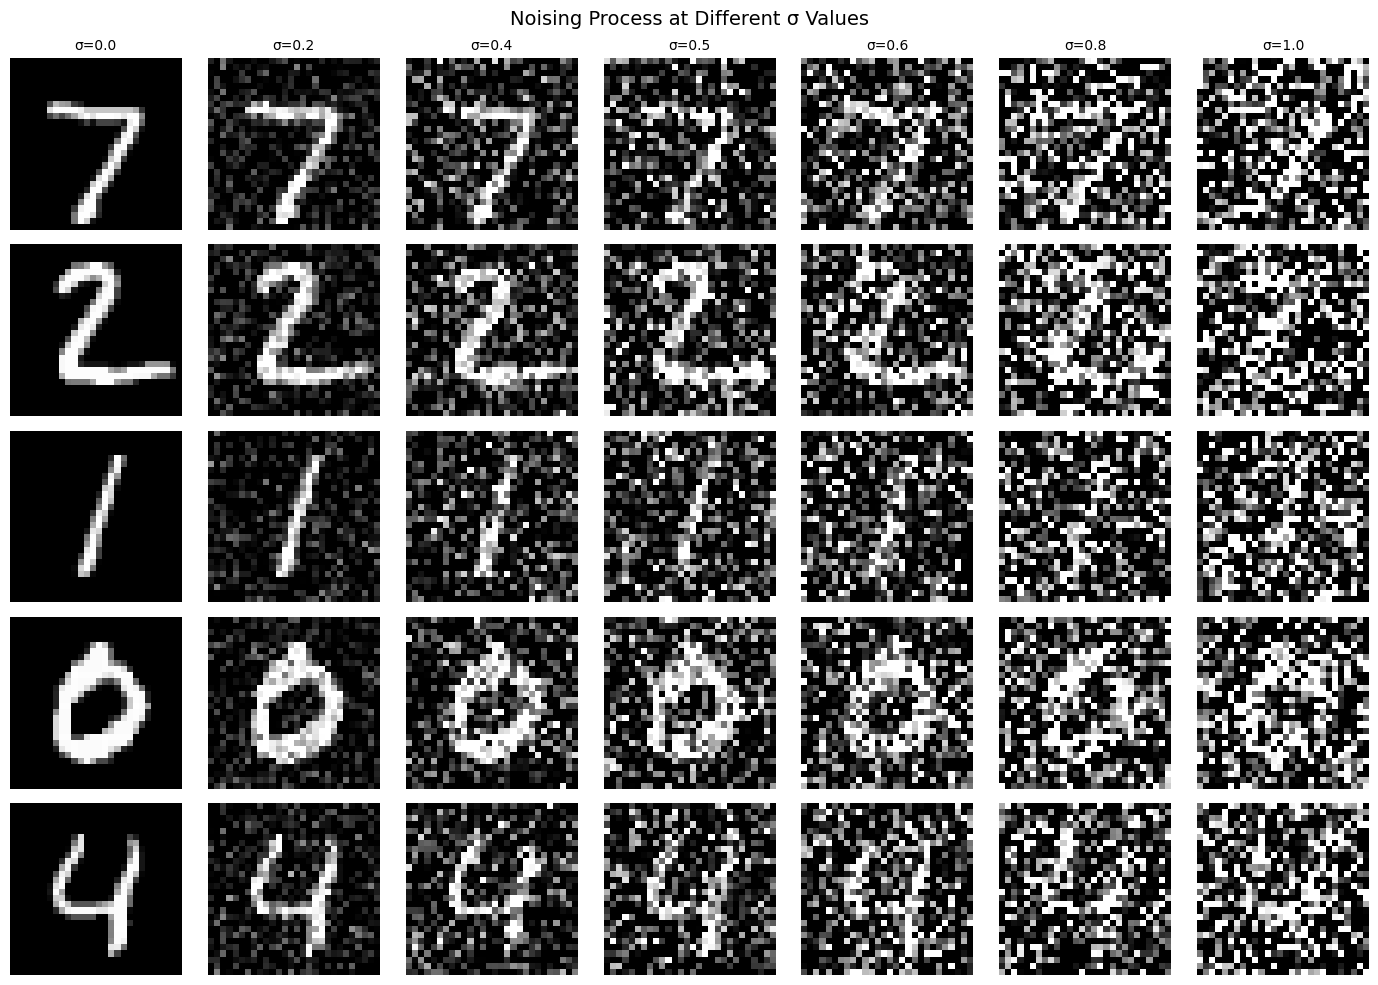

Saved part1_noising_visualization.png


In [6]:
# Visualize images at different noisy level
# ===== your code here! ====
# Load test dataset to get some sample images for visualization
test_dataset_vis = MNIST(root='./data', train=False, download=True, transform=ToTensor())

# Get a batch of clean images for visualization
sample_images = torch.stack([test_dataset_vis[i][0] for i in range(5)])  # (5, 1, 28, 28)

# Visualize images at different noisy levels
sigmas = [0.0, 0.2, 0.4, 0.5, 0.6, 0.8, 1.0]

fig, axes = plt.subplots(len(sample_images), len(sigmas), figsize=(14, 10))
for row, img in enumerate(sample_images):
    for col, sigma in enumerate(sigmas):
        eps = torch.randn_like(img)
        noisy = img + sigma * eps
        noisy_np = noisy.squeeze().clamp(0, 1).numpy()
        axes[row, col].imshow(noisy_np, cmap='gray')
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(f'σ={sigma}', fontsize=10)

plt.suptitle('Noising Process at Different σ Values', fontsize=14)
plt.tight_layout()
plt.savefig('part1_noising_visualization.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved part1_noising_visualization.png')
# ===== end of code ====

## Part 1.2.1: Training

For this part, we provide some structure code for training. It is very basic, so feel free to change them or add your code. In later section we won't provide any training or visualization structure code.

In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Set your hyperparameters
# ===== your code here! ====
batch_size = 256
learning_rate = 1e-4
noise_level = 0.5    # sigma for denoising task
hidden_dim = 128
num_epochs = 5
# ===== end of code ====

Using device: cuda


In [8]:
# Define your datasets and dataloaders
# ===== your code here! ====
train_dataset = MNIST(root='./data', train=True, download=True, transform=ToTensor())
test_dataset = MNIST(root='./data', train=False, download=True, transform=ToTensor())
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
# ===== end of code ====

In [9]:
# Define your model, optimizer, and loss
# ===== your code here! ====
model = UnconditionalUNet(in_channels=1, num_hiddens=hidden_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.MSELoss()
# ===== end of code ====

In [10]:
def add_noise(images, sigma):
    """Add Gaussian noise: z = x + sigma * eps."""
    eps = torch.randn_like(images)
    return images + sigma * eps

def visualize_denoising(model, test_loader, sigma, epoch, save_path=None, n=8):
    """Visualize denoising on test set."""
    model.eval()
    with torch.no_grad():
        images, _ = next(iter(test_loader))
        images = images[:n].to(device)
        noisy = add_noise(images, sigma)
        denoised = model(noisy)

    fig, axes = plt.subplots(3, n, figsize=(2 * n, 6))
    for i in range(n):
        axes[0, i].imshow(images[i].cpu().squeeze().clamp(0,1), cmap='gray')
        axes[0, i].axis('off')
        axes[1, i].imshow(noisy[i].cpu().squeeze().clamp(0,1), cmap='gray')
        axes[1, i].axis('off')
        axes[2, i].imshow(denoised[i].cpu().squeeze().clamp(0,1), cmap='gray')
        axes[2, i].axis('off')

    axes[0, 0].set_ylabel('Clean', fontsize=10)
    axes[1, 0].set_ylabel('Noisy', fontsize=10)
    axes[2, 0].set_ylabel('Denoised', fontsize=10)
    plt.suptitle(f'Denoising Results (epoch={epoch}, σ={sigma})', fontsize=12)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=100, bbox_inches='tight')
    plt.show()

Epoch 1/5: 100%|██████████| 235/235 [03:48<00:00,  1.03it/s]


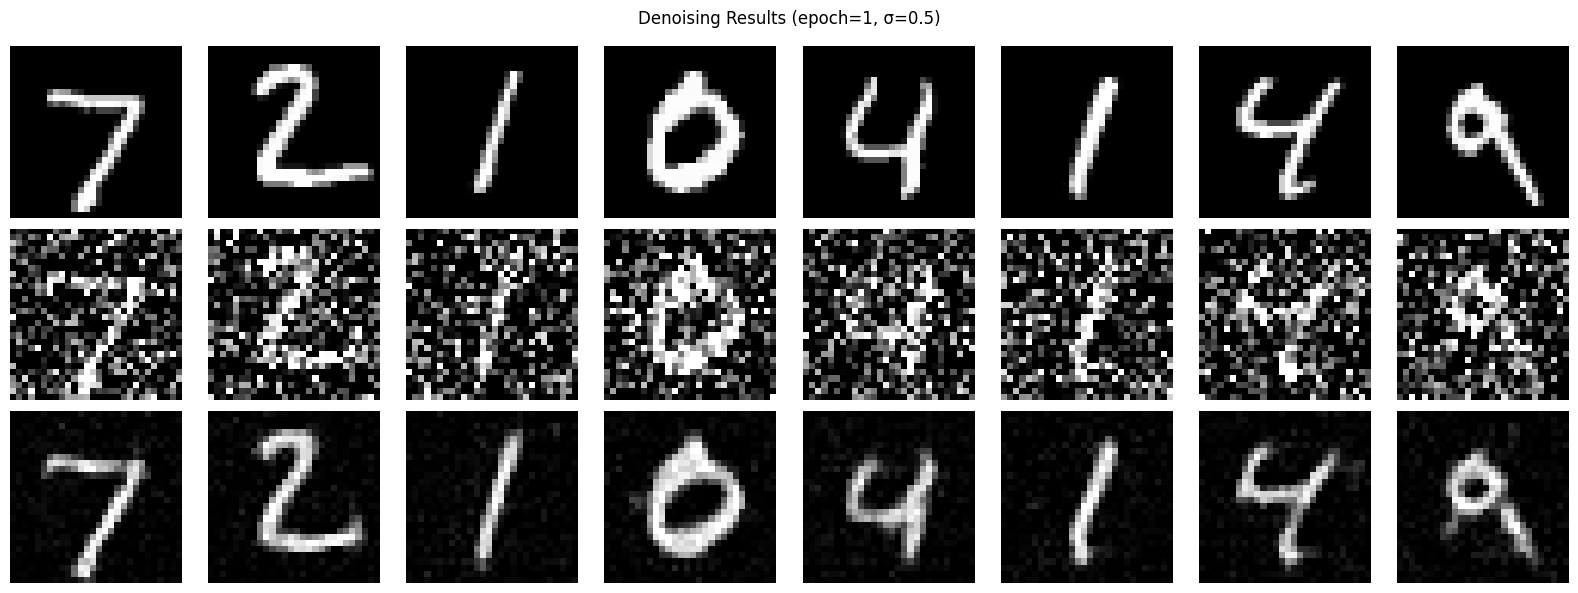

Epoch 5/5: 100%|██████████| 235/235 [03:57<00:00,  1.01s/it]


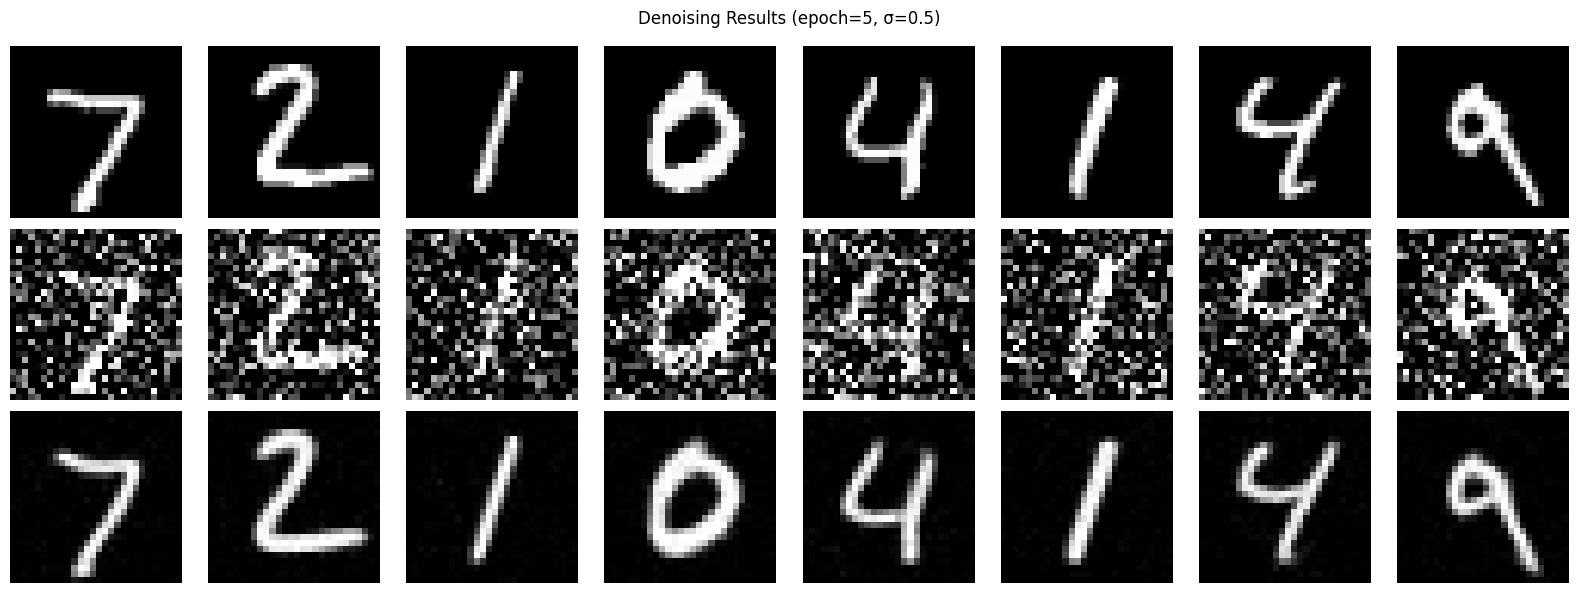

In [11]:
# The training loops
train_losses = []
for epoch in range(1, num_epochs + 1):
    model.train()
    for i, (images, _) in enumerate(tqdm(train_loader, desc=f'Epoch {epoch}/{num_epochs}')):
        images = images.to(device)

        # Add noise to get z = x + sigma * eps
        noisy_images = add_noise(images, noise_level)

        # Forward pass: predict clean from noisy
        outputs = model(noisy_images)

        loss = criterion(outputs, images)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

    # Visualize after epoch 1 and epoch 5
    if epoch == 1 or epoch == num_epochs:
        visualize_denoising(
            model, test_loader, noise_level, epoch,
            save_path=f'part1_denoising_epoch{epoch}.png'
        )

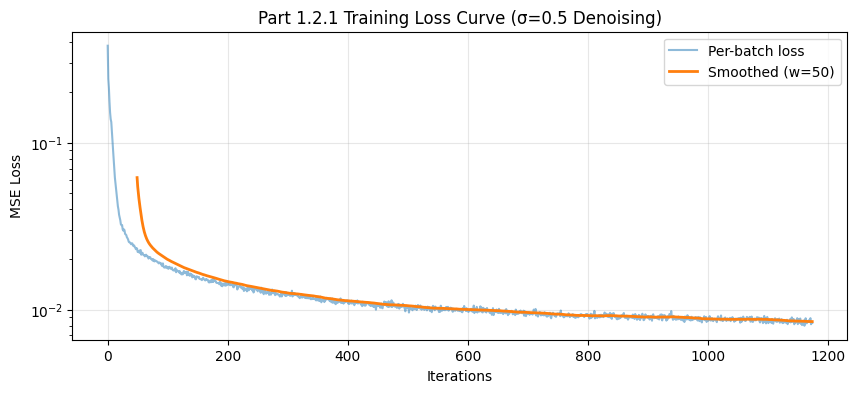

In [12]:
# Visualize your training curve
# ===== your code here! ====
plt.figure(figsize=(10, 4))
plt.plot(train_losses, alpha=0.5, label='Per-batch loss')

# Smoothed curve
window = 50
smoothed = np.convolve(train_losses, np.ones(window)/window, mode='valid')
plt.plot(range(window-1, len(train_losses)), smoothed, label=f'Smoothed (w={window})', linewidth=2)

plt.xlabel('Iterations')
plt.ylabel('MSE Loss')
plt.title('Part 1.2.1 Training Loss Curve (σ=0.5 Denoising)')
plt.legend()
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.savefig('part1_training_curve.png', dpi=100, bbox_inches='tight')
plt.show()
# ===== end of code ====

## Part 1.2.2: Out-of-Distribution Testing

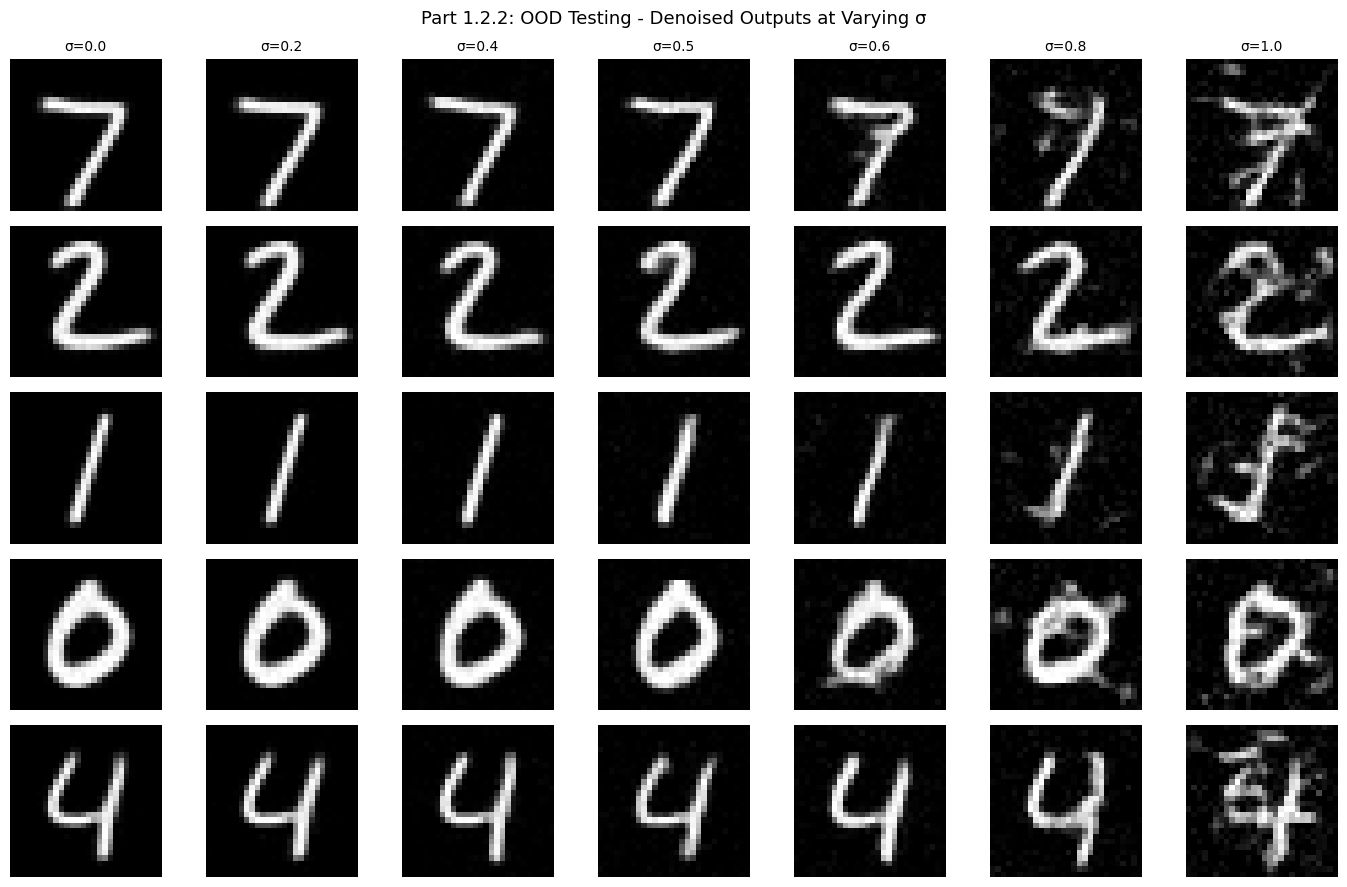

In [13]:
# Visualize OOD testing
# ===== your code here! ====
# Visualize OOD testing: same images at different sigma levels
sigmas_ood = [0.0, 0.2, 0.4, 0.5, 0.6, 0.8, 1.0]
n_images = 5

model.eval()
with torch.no_grad():
    test_images, _ = next(iter(test_loader))
    test_images = test_images[:n_images].to(device)

fig, axes = plt.subplots(n_images, len(sigmas_ood), figsize=(14, 9))
for col, sigma in enumerate(sigmas_ood):
    with torch.no_grad():
        noisy = add_noise(test_images, sigma)
        denoised = model(noisy)
    for row in range(n_images):
        axes[row, col].imshow(denoised[row].cpu().squeeze().clamp(0, 1), cmap='gray')
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(f'σ={sigma}', fontsize=10)

plt.suptitle('Part 1.2.2: OOD Testing - Denoised Outputs at Varying σ', fontsize=13)
plt.tight_layout()
plt.savefig('part1_ood_testing.png', dpi=100, bbox_inches='tight')
plt.show()
# ===== end of code ====

## Part 1.2.3 Denoising Pure Noise

Epoch 1/5 (pure noise): 100%|██████████| 235/235 [03:59<00:00,  1.02s/it]


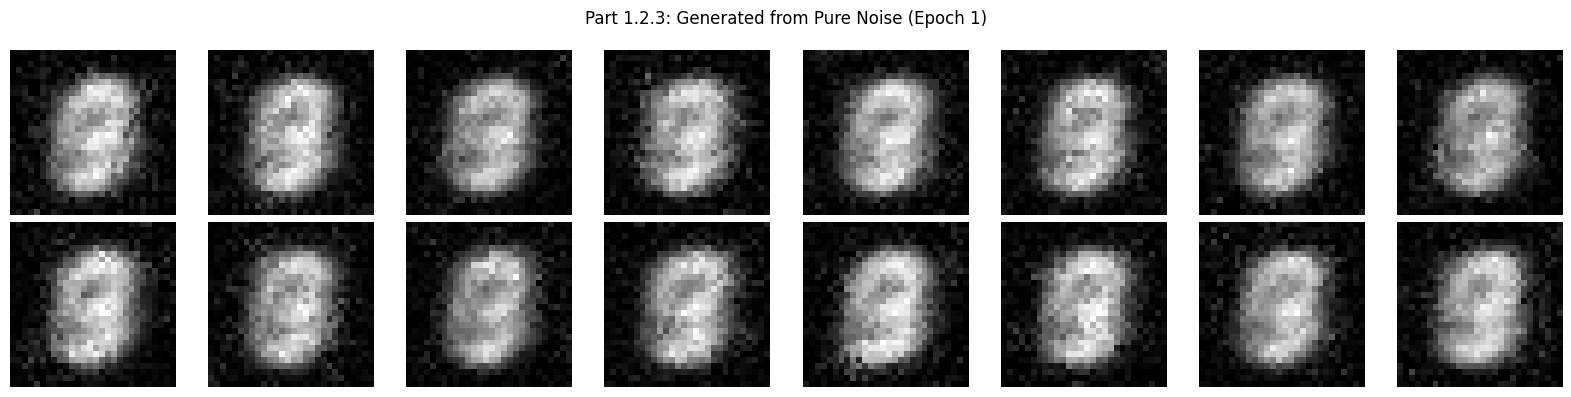

Epoch 5/5 (pure noise): 100%|██████████| 235/235 [03:56<00:00,  1.01s/it]


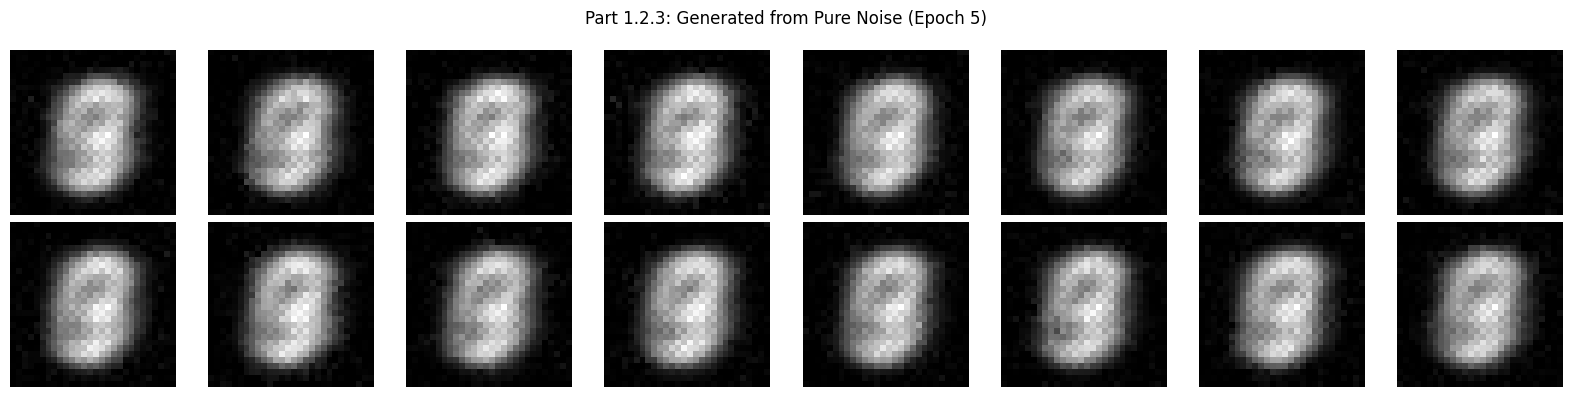

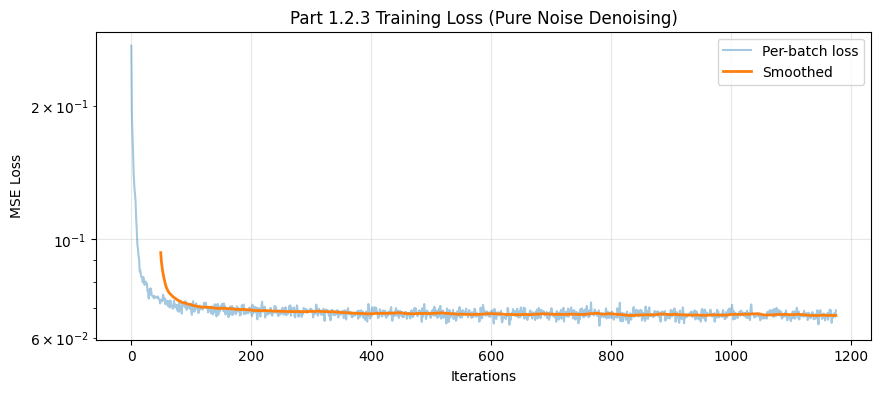


Pattern Analysis:
The generated images from pure noise denoising tend to look like blurry, averaged versions
of all MNIST digits. This is because with MSE loss, the model learns to predict the
conditional expectation E[x | z]. When z is pure random noise with no digit information,
this expectation is approximately the mean image across all training samples — a blurry
average of all digits. The model collapses to the centroid of the training distribution,
which explains why outputs look like ghostly, indistinct digit-like shapes rather than
sharp, specific digits.



In [14]:
# Feel free to use code from part 1.2.1
# as they should be very similar
# ===== your code here! ====
#Train a new model to denoise pure Gaussian noise
# Input: eps ~ N(0, I), Target: clean x
model_pure = UnconditionalUNet(in_channels=1, num_hiddens=hidden_dim).to(device)
optimizer_pure = torch.optim.Adam(model_pure.parameters(), lr=learning_rate)

train_losses_pure = []
for epoch in range(1, num_epochs + 1):
    model_pure.train()
    for i, (images, _) in enumerate(tqdm(train_loader, desc=f'Epoch {epoch}/{num_epochs} (pure noise)')):
        images = images.to(device)

        # Pure noise input (sigma=1, but fully random noise, not x + sigma*eps)
        pure_noise = torch.randn_like(images)

        outputs = model_pure(pure_noise)
        loss = criterion(outputs, images)
        optimizer_pure.zero_grad()
        loss.backward()
        optimizer_pure.step()

        train_losses_pure.append(loss.item())

    if epoch == 1 or epoch == num_epochs:
        # Sample from pure noise
        model_pure.eval()
        with torch.no_grad():
            noise_samples = torch.randn(16, 1, 28, 28).to(device)
            generated = model_pure(noise_samples)

        fig, axes = plt.subplots(2, 8, figsize=(16, 4))
        for idx in range(16):
            r, c = idx // 8, idx % 8
            axes[r, c].imshow(generated[idx].cpu().squeeze().clamp(0,1), cmap='gray')
            axes[r, c].axis('off')
        plt.suptitle(f'Part 1.2.3: Generated from Pure Noise (Epoch {epoch})', fontsize=12)
        plt.tight_layout()
        plt.savefig(f'part1_pure_noise_epoch{epoch}.png', dpi=100, bbox_inches='tight')
        plt.show()

# Plot training curve for pure noise
plt.figure(figsize=(10, 4))
plt.plot(train_losses_pure, alpha=0.4, label='Per-batch loss')
smoothed_p = np.convolve(train_losses_pure, np.ones(window)/window, mode='valid')
plt.plot(range(window-1, len(train_losses_pure)), smoothed_p, label='Smoothed', linewidth=2)
plt.xlabel('Iterations')
plt.ylabel('MSE Loss')
plt.title('Part 1.2.3 Training Loss (Pure Noise Denoising)')
plt.legend()
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.savefig('part1_pure_noise_curve.png', dpi=100, bbox_inches='tight')
plt.show()

print("""\nPattern Analysis:
The generated images from pure noise denoising tend to look like blurry, averaged versions
of all MNIST digits. This is because with MSE loss, the model learns to predict the
conditional expectation E[x | z]. When z is pure random noise with no digit information,
this expectation is approximately the mean image across all training samples — a blurry
average of all digits. The model collapses to the centroid of the training distribution,
which explains why outputs look like ghostly, indistinct digit-like shapes rather than
sharp, specific digits.
""")
# ===== end of code ====

# Part 2: Flow Matching

# Part 2.1: Implementing a Time-conditioned UNet

In [15]:
class FCBlock(nn.Module):
    """Fully-connected block: Linear -> GELU -> Linear -> GELU.
    Used to embed scalar conditioning signals (time t, class c).
    """
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        # ===== your code here! ====
        self.net = nn.Sequential(
            nn.Linear(in_channels, out_channels),
            nn.GELU(),
            nn.Linear(out_channels, out_channels),
            nn.GELU(),
        )
        # ===== end of code ====


    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ===== your code here! ====
        return self.net(x)
        # ===== end of code ====
        raise NotImplementedError()


class TimeConditionalUNet(nn.Module):
    """
    UNet conditioned on scalar time t in [0, 1].

    Time conditioning via FCBlocks that scale (multiply) the unflatten and up1 activations.
    FCBlock outputs are reshaped to (N, D, 1, 1) for broadcasting over spatial dims.
    """
    def __init__(
        self,
        in_channels: int,
        num_hiddens: int,
    ):
        super().__init__()
        # ===== your code here! ====
        D = num_hiddens

        # Encoder
        self.conv_in = ConvBlock(in_channels, D)     # 28x28, D
        self.down1 = DownBlock(D, 2 * D)             # 14x14, 2D
        self.down2 = DownBlock(2 * D, 4 * D)         # 7x7,   4D
        self.flatten = Flatten()                      # 1x1,   4D

        # Bottleneck
        self.unflatten = Unflatten(4 * D)             # 7x7,   4D

        # Decoder
        self.up1 = UpBlock(4 * D + 4 * D, 2 * D)    # 14x14, 2D
        self.up2 = UpBlock(2 * D + 2 * D, D)         # 28x28, D
        self.conv_out = nn.Conv2d(D + D, in_channels, kernel_size=1)

        # Time conditioning: two FCBlocks for unflatten and up1
        # t is scalar (F_in=1), output D_out channels to match activation channels
        self.fc1_t = FCBlock(1, 4 * D)   # modulates unflatten output (4D)
        self.fc2_t = FCBlock(1, 2 * D)   # modulates up1 output (2D)
        # ===== end of code ====


    def forward(
        self,
        x: torch.Tensor,
        t: torch.Tensor,
    ) -> torch.Tensor:
        # ===== your code here! ====
        """
        Args:
            x: (N, C, H, W) input tensor.
            t: (N,) normalized time tensor in [0, 1].

        Returns:
            (N, C, H, W) output tensor.
        """
        assert x.shape[-2:] == (28, 28), "Expect input shape to be (28, 28)."

        # Embed time: t shape (N,) -> (N, 1)
        t_emb = t.unsqueeze(1).float()  # (N, 1)
        t1 = self.fc1_t(t_emb).unsqueeze(-1).unsqueeze(-1)  # (N, 4D, 1, 1)
        t2 = self.fc2_t(t_emb).unsqueeze(-1).unsqueeze(-1)  # (N, 2D, 1, 1)

        # Encoder
        x0 = self.conv_in(x)     # (N, D, 28, 28)
        x1 = self.down1(x0)      # (N, 2D, 14, 14)
        x2 = self.down2(x1)      # (N, 4D, 7, 7)
        xf = self.flatten(x2)    # (N, 4D, 1, 1)

        # Bottleneck
        xu = self.unflatten(xf)  # (N, 4D, 7, 7)
        xu = xu * t1             # time-modulated unflatten

        # Decoder with skip connections
        xu = self.up1(torch.cat([xu, x2], dim=1))  # (N, 2D, 14, 14)
        xu = xu * t2                                 # time-modulated up1
        xu = self.up2(torch.cat([xu, x1], dim=1))  # (N, D, 28, 28)
        xu = self.conv_out(torch.cat([xu, x0], dim=1))  # (N, 1, 28, 28)
        return xu
        # ===== end of code ====
        raise NotImplementedError()

## Implementing the Forward and Reverse Process for Time-conditioned Denoising

In [16]:
def time_fm_forward(
    unet: TimeConditionalUNet,
    x_1: torch.Tensor,
    num_ts: int,
) -> torch.Tensor:
    """Algorithm 1: Flow Matching training step.

    Samples t ~ U[0,1], x_0 ~ N(0,I), computes x_t = (1-t)*x_0 + t*x_1,
    target flow = x_1 - x_0, returns MSE loss between predicted and true flow.

    Args:
        unet: TimeConditionalUNet
        x_1: (N, C, H, W) clean image batch.
        num_ts: int, number of discrete timesteps (used for quantizing t).
    Returns:
        (,) scalar loss.
    """
    unet.train()
    # ===== your code here! ====
    N = x_1.shape[0]
    device = x_1.device

    # Sample t uniformly from {0/T, 1/T, ..., (T-1)/T}
    # or just uniform continuous in [0, 1]
    t = torch.rand(N, device=device)  # (N,) in [0, 1]

    # Sample noise
    x_0 = torch.randn_like(x_1)  # (N, C, H, W)

    # Interpolate: x_t = (1-t)*x_0 + t*x_1
    t_view = t.view(N, 1, 1, 1)
    x_t = (1 - t_view) * x_0 + t_view * x_1

    # Target flow: u = x_1 - x_0
    u_target = x_1 - x_0

    # Predict flow
    u_pred = unet(x_t, t)

    # MSE loss
    loss = F.mse_loss(u_pred, u_target)
    return loss
    # ===== end of code ====
    raise NotImplementedError()

In [17]:
@torch.inference_mode()
def time_fm_sample(
    unet: TimeConditionalUNet,
    img_wh: tuple,
    num_ts: int,
    n_samples: int = 16,
    seed: int = 0,
) -> torch.Tensor:
    """Algorithm 2: Euler-method sampling from time-conditioned UNet.

    Starts from x_0 ~ N(0, I) and iteratively applies the predicted flow
    using the Euler method: x_{t+dt} = x_t + u_theta(x_t, t) * dt.

    Args:
        unet: TimeConditionalUNet
        img_wh: (H, W) output image height and width.
        num_ts: int, number of Euler steps.
        n_samples: int, number of images to generate.
        seed: int, random seed.

    Returns:
        (N, C, H, W) final sample, values in approximately [0, 1].
    """
    unet.eval()
    # ===== your code here! ====
    torch.manual_seed(seed)
    device = next(unet.parameters()).device
    H, W = img_wh

    # Start from pure Gaussian noise
    x = torch.randn(n_samples, 1, H, W, device=device)

    # Euler integration from t=0 to t=1
    dt = 1.0 / num_ts
    for i in range(num_ts):
        t = torch.full((n_samples,), i / num_ts, device=device)
        u = unet(x, t)          # predicted flow
        x = x + u * dt          # Euler step

    return x
    # ===== end of code ====
    raise NotImplementedError()

In [18]:
class TimeConditionalFM(nn.Module):
    def __init__(
        self,
        unet: TimeConditionalUNet,
        num_ts: int = 50,
        img_hw: tuple = (28, 28),
    ):
        super().__init__()
        self.unet = unet
        self.num_ts = num_ts
        self.img_hw = img_hw

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: (N, C, H, W) input tensor.

        Returns:
            (,) flow matching loss.
        """
        return time_fm_forward(self.unet, x, self.num_ts)

    @torch.inference_mode()
    def sample(self, img_wh: tuple, seed: int = 0):
        return time_fm_sample(self.unet, img_wh, self.num_ts, seed=seed)

# Part 2.2: Training the Time-conditioned UNet

In [19]:
# Feel free to use code from part 1.2.1
# as they should be very similar
# ===== your code here! ====
# Hyperparameters for flow matching
fm_batch_size = 64
fm_lr = 1e-2
fm_hidden_dim = 64
fm_num_epochs = 10
fm_num_ts = 50  # Euler steps for sampling

fm_train_loader = DataLoader(
    train_dataset, batch_size=fm_batch_size, shuffle=True, num_workers=2, pin_memory=True
)

# Model
fm_unet = TimeConditionalUNet(in_channels=1, num_hiddens=fm_hidden_dim).to(device)
fm_model = TimeConditionalFM(fm_unet, num_ts=fm_num_ts)
fm_optimizer = torch.optim.Adam(fm_unet.parameters(), lr=fm_lr)
# Exponential LR decay: gamma = 0.1^(1/num_epochs)
fm_scheduler = torch.optim.lr_scheduler.ExponentialLR(
    fm_optimizer, gamma=0.1 ** (1.0 / fm_num_epochs)
)

print(f'TimeConditionalUNet params: {sum(p.numel() for p in fm_unet.parameters()):,}')
# ===== end of code ====

TimeConditionalUNet params: 5,753,729


FM Epoch 1/10: 100%|██████████| 938/938 [01:00<00:00, 15.55it/s]


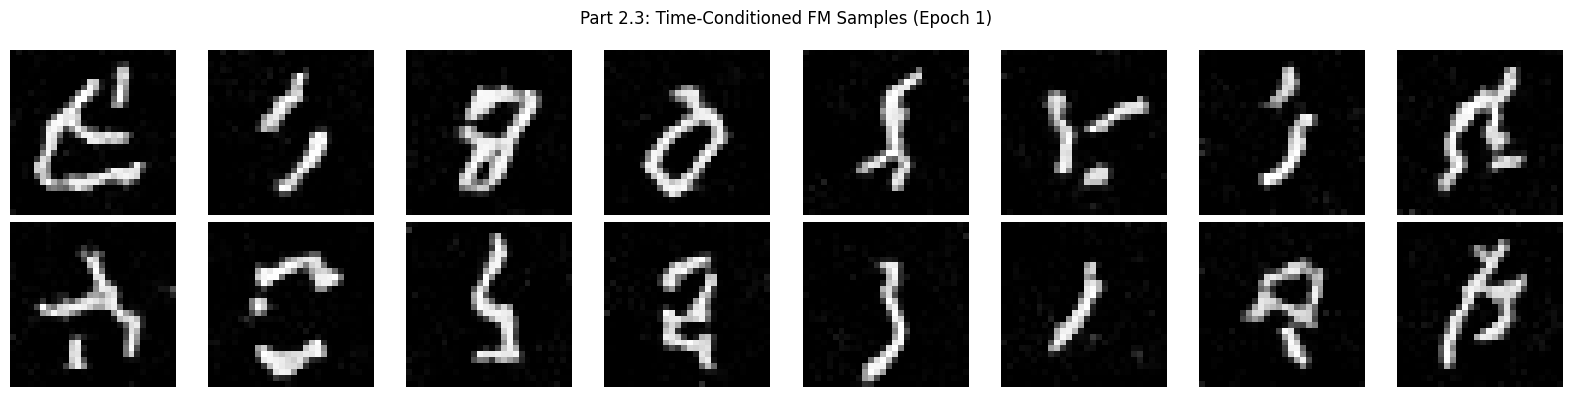

Saved fm_samples/part2_tc_epoch1.png


FM Epoch 5/10: 100%|██████████| 938/938 [00:58<00:00, 15.93it/s]


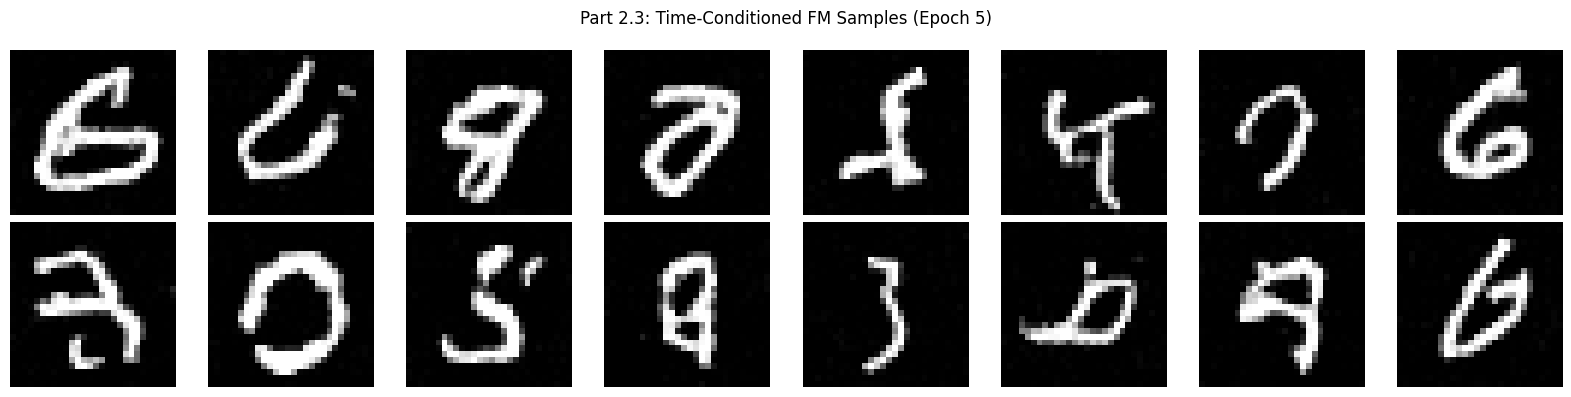

Saved fm_samples/part2_tc_epoch5.png


FM Epoch 10/10: 100%|██████████| 938/938 [00:58<00:00, 15.94it/s]


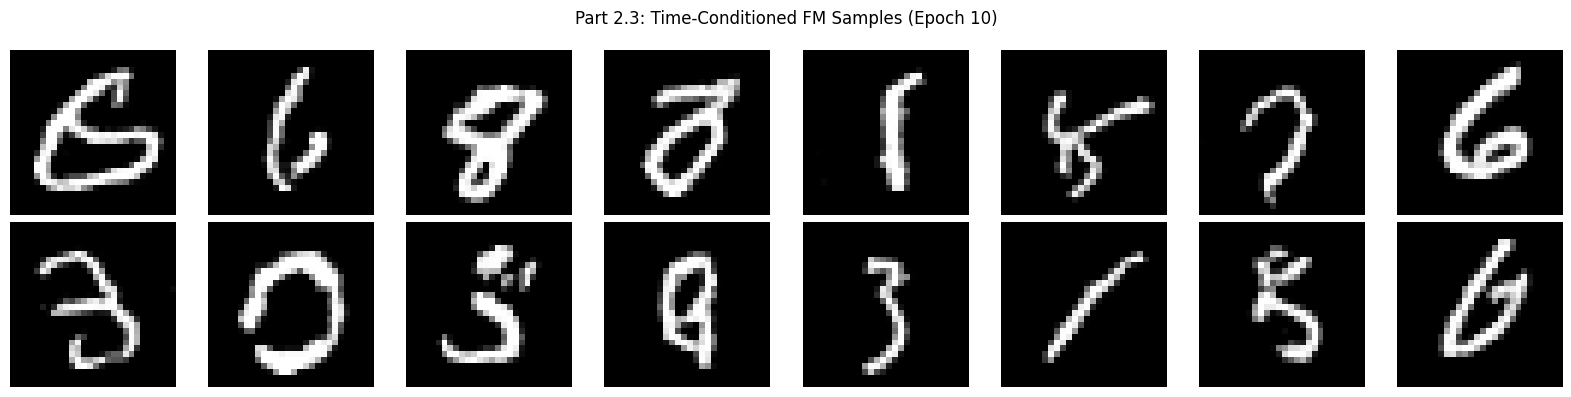

Saved fm_samples/part2_tc_epoch10.png


In [20]:
fm_train_losses = []
sample_epochs = [1, 5, 10]
os.makedirs('fm_samples', exist_ok=True)

for epoch in range(1, fm_num_epochs + 1):
    fm_unet.train()
    epoch_loss = 0.0
    for images, _ in tqdm(fm_train_loader, desc=f'FM Epoch {epoch}/{fm_num_epochs}'):
        images = images.to(device)

        loss = time_fm_forward(fm_unet, images, fm_num_ts)
        fm_optimizer.zero_grad()
        loss.backward()
        fm_optimizer.step()

        fm_train_losses.append(loss.item())

    fm_scheduler.step()

    # Sample at specific epochs
    if epoch in sample_epochs:
        samples = time_fm_sample(fm_unet, (28, 28), fm_num_ts, n_samples=16, seed=42)
        fig, axes = plt.subplots(2, 8, figsize=(16, 4))
        for idx in range(16):
            r, c = idx // 8, idx % 8
            axes[r, c].imshow(samples[idx].cpu().squeeze().clamp(0, 1), cmap='gray')
            axes[r, c].axis('off')
        plt.suptitle(f'Part 2.3: Time-Conditioned FM Samples (Epoch {epoch})', fontsize=12)
        plt.tight_layout()
        path = f'fm_samples/part2_tc_epoch{epoch}.png'
        plt.savefig(path, dpi=100, bbox_inches='tight')
        plt.show()
        print(f'Saved {path}')

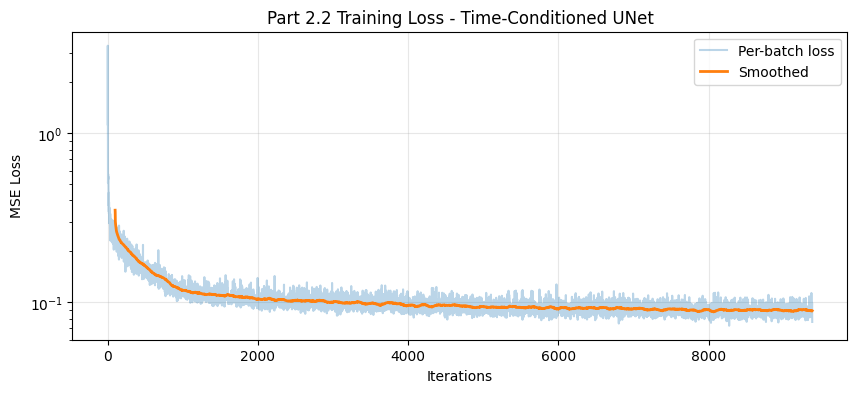

In [22]:
# Training curve
plt.figure(figsize=(10, 4))
plt.plot(fm_train_losses, alpha=0.3, label='Per-batch loss')
w = 100
s = np.convolve(fm_train_losses, np.ones(w)/w, mode='valid')
plt.plot(range(w-1, len(fm_train_losses)), s, label='Smoothed', linewidth=2)
plt.xlabel('Iterations')
plt.ylabel('MSE Loss')
plt.title('Part 2.2 Training Loss - Time-Conditioned UNet')
plt.legend()
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.savefig('part2_tc_training_curve.png', dpi=100, bbox_inches='tight')
plt.show()

# Part 2.3: Sampling from the Time-conditioned UNet


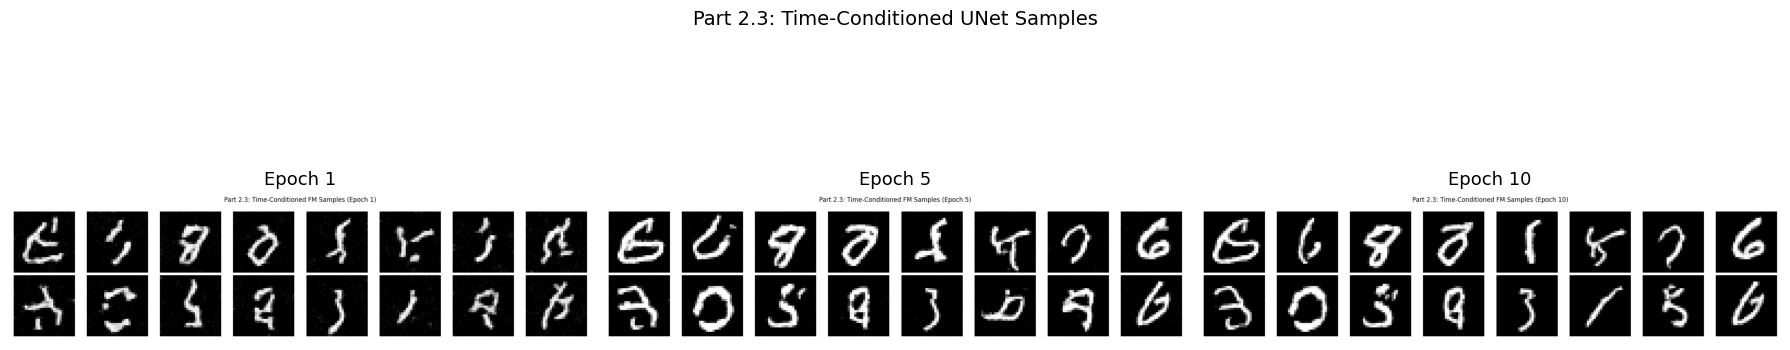

In [31]:
# ===== your code here! ====
# Epoch-specific samples (epochs 1, 5, 10) were already saved to disk during training.
# This cell loads and displays them for the deliverable.

import matplotlib.image as mpimg

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, ep in zip(axes, [1, 5, 10]):
    path = f'fm_samples/part2_tc_epoch{ep}.png'
    try:
        img = mpimg.imread(path)
        ax.imshow(img)
        ax.set_title(f'Epoch {ep}', fontsize=13)
        ax.axis('off')
    except FileNotFoundError:
        # If images weren't saved (e.g. notebook re-run without training),
        # re-generate samples using the current (final) model state.
        samples = time_fm_sample(fm_unet, (28, 28), fm_num_ts, n_samples=16, seed=42)
        samples_np = samples.cpu().clamp(0, 1)  # (16, 1, 28, 28)
        # Build a grid manually
        grid_rows = []
        for row in range(2):
            grid_rows.append(
                torch.cat([samples_np[row*8 + c].squeeze() for c in range(8)], dim=1)
            )
        grid = torch.cat(grid_rows, dim=0).numpy()
        ax.imshow(grid, cmap='gray')
        ax.set_title(f'Epoch {ep} (re-sampled, final model)', fontsize=11)
        ax.axis('off')
        plt.savefig(path, dpi=100, bbox_inches='tight')

plt.suptitle('Part 2.3: Time-Conditioned UNet Samples', fontsize=14)
plt.tight_layout()
plt.savefig('fm_samples/part2_tc_all_epochs.png', dpi=100, bbox_inches='tight')
plt.show()
# ===== end of code ====

# Part 2.4: Implementing a Class-conditioned UNet

In [23]:
class ClassConditionalUNet(nn.Module):
    """
    UNet conditioned on both time t (scalar) and class c (one-hot, 10 classes).

    Conditioning:
      unflatten = c1 * unflatten + t1
      up1       = c2 * up1       + t2
    """
    def __init__(
        self,
        in_channels: int,
        num_classes: int,
        num_hiddens: int,
    ):
        super().__init__()
        # ===== your code here! ====
        D = num_hiddens

        # Encoder
        self.conv_in = ConvBlock(in_channels, D)
        self.down1 = DownBlock(D, 2 * D)
        self.down2 = DownBlock(2 * D, 4 * D)
        self.flatten = Flatten()

        # Bottleneck
        self.unflatten = Unflatten(4 * D)

        # Decoder
        self.up1 = UpBlock(4 * D + 4 * D, 2 * D)
        self.up2 = UpBlock(2 * D + 2 * D, D)
        self.conv_out = nn.Conv2d(D + D, in_channels, kernel_size=1)

        # Time conditioning FCBlocks
        self.fc1_t = FCBlock(1, 4 * D)
        self.fc2_t = FCBlock(1, 2 * D)

        # Class conditioning FCBlocks (one-hot input)
        self.fc1_c = FCBlock(num_classes, 4 * D)
        self.fc2_c = FCBlock(num_classes, 2 * D)

        self.num_classes = num_classes
        # ===== end of code ====

    def forward(
        self,
        x: torch.Tensor,
        c: torch.Tensor,
        t: torch.Tensor,
        mask: torch.Tensor | None = None,
    ) -> torch.Tensor:
        """
        Args:
            x: (N, C, H, W) input tensor.
            c: (N,) int64 condition tensor.
            t: (N,) normalized time tensor.
            mask: (N,) mask tensor. If not None, mask out condition when mask == 0.

        Returns:
            (N, C, H, W) output tensor.
        """
        assert x.shape[-2:] == (28, 28), "Expect input shape to be (28, 28)."
        # ===== your code here! ====
        N = x.shape[0]
        device = x.device

        # One-hot encode class
        c_onehot = F.one_hot(c, num_classes=self.num_classes).float()  # (N, num_classes)

        # Apply dropout mask (set to zeros when mask==0 for CFG)
        if mask is not None:
            c_onehot = c_onehot * mask.unsqueeze(1).float()

        # Embed time and class
        t_emb = t.unsqueeze(1).float()  # (N, 1)

        t1 = self.fc1_t(t_emb).unsqueeze(-1).unsqueeze(-1)        # (N, 4D, 1, 1)
        t2 = self.fc2_t(t_emb).unsqueeze(-1).unsqueeze(-1)        # (N, 2D, 1, 1)
        c1 = self.fc1_c(c_onehot).unsqueeze(-1).unsqueeze(-1)     # (N, 4D, 1, 1)
        c2 = self.fc2_c(c_onehot).unsqueeze(-1).unsqueeze(-1)     # (N, 2D, 1, 1)

        # Encoder
        x0 = self.conv_in(x)
        x1 = self.down1(x0)
        x2 = self.down2(x1)
        xf = self.flatten(x2)

        # Bottleneck + class+time modulation
        xu = self.unflatten(xf)
        xu = c1 * xu + t1     # class scales, time shifts

        # Decoder
        xu = self.up1(torch.cat([xu, x2], dim=1))
        xu = c2 * xu + t2
        xu = self.up2(torch.cat([xu, x1], dim=1))
        xu = self.conv_out(torch.cat([xu, x0], dim=1))
        return xu
        # ===== end of code ====
        raise NotImplementedError()

In [24]:
def class_fm_forward(
    unet: ClassConditionalUNet,
    x_1: torch.Tensor,
    c: torch.Tensor,
    p_uncond: float,
    num_ts: int,
) -> torch.Tensor:
    """Algorithm 3: Class-conditioned flow matching training step.

    With probability p_uncond, drops the class condition (sets mask=0).

    Args:
        unet: ClassConditionalUNet
        x_1: (N, C, H, W) clean image batch.
        c: (N,) int64 class labels.
        p_uncond: probability of unconditional training (condition dropout).
        num_ts: int, number of timesteps (used for quantizing t if needed).

    Returns:
        (,) scalar loss.
    """
    unet.train()
    # ===== your code here! ====
    N = x_1.shape[0]
    device = x_1.device

    # Sample t ~ U[0, 1]
    t = torch.rand(N, device=device)

    # Sample noise
    x_0 = torch.randn_like(x_1)

    # Interpolate
    t_view = t.view(N, 1, 1, 1)
    x_t = (1 - t_view) * x_0 + t_view * x_1

    # Target flow
    u_target = x_1 - x_0

    # CFG dropout mask: 1=use class, 0=drop class
    mask = (torch.rand(N, device=device) >= p_uncond).long()

    # Predict flow
    u_pred = unet(x_t, c, t, mask=mask)

    return F.mse_loss(u_pred, u_target)
    # ===== end of code ====
    raise NotImplementedError()

In [25]:
@torch.inference_mode()
def class_fm_sample(
    unet: ClassConditionalUNet,
    c: torch.Tensor,
    img_wh: tuple,
    num_ts: int,
    guidance_scale: float = 5.0,
    seed: int = 0,
) -> tuple:
    """Algorithm 4: Classifier-free guidance sampling.

    u_cfg = u_uncond + gamma * (u_cond - u_uncond)

    Args:
        unet: ClassConditionalUNet
        c: (N,) int64 condition tensor.
        img_wh: (H, W) output image height and width.
        num_ts: int, number of Euler steps.
        guidance_scale: float, CFG scale gamma.
        seed: int, random seed.

    Returns:
        (N, C, H, W) final sample.
        (N, T_animation, C, H, W) intermediate caches for animation.
    """
    unet.eval()
    # ===== your code here! ====
    torch.manual_seed(seed)
    device = next(unet.parameters()).device
    H, W = img_wh
    N = c.shape[0]

    # Start from pure Gaussian noise
    x = torch.randn(N, 1, H, W, device=device)

    # Masks for conditional and unconditional
    mask_cond = torch.ones(N, dtype=torch.long, device=device)    # use class
    mask_uncond = torch.zeros(N, dtype=torch.long, device=device)  # drop class

    # Animation cache
    caches = []
    cache_steps = set(range(0, num_ts, max(1, num_ts // 10)))  # ~10 frames

    dt = 1.0 / num_ts
    for i in range(num_ts):
        t = torch.full((N,), i / num_ts, device=device)

        # Conditional and unconditional predictions
        u_cond = unet(x, c, t, mask=mask_cond)
        u_uncond = unet(x, c, t, mask=mask_uncond)

        # CFG
        u_cfg = u_uncond + guidance_scale * (u_cond - u_uncond)

        x = x + u_cfg * dt

        if i in cache_steps:
            caches.append(x.unsqueeze(1))  # (N, 1, C, H, W)

    caches = torch.cat(caches, dim=1)  # (N, T, C, H, W)
    return x, caches
    # ===== end of code ====
    raise NotImplementedError()

In [26]:
class ClassConditionalFM(nn.Module):
    def __init__(
        self,
        unet: ClassConditionalUNet,
        num_ts: int = 300,
        p_uncond: float = 0.1,
    ):
        super().__init__()
        self.unet = unet
        self.num_ts = num_ts
        self.p_uncond = p_uncond

    def forward(self, x: torch.Tensor, c: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: (N, C, H, W) input tensor.
            c: (N,) int64 condition tensor.

        Returns:
            (,) loss.
        """
        return class_fm_forward(
            self.unet, x, c, self.p_uncond, self.num_ts
        )

    @torch.inference_mode()
    def sample(
        self,
        c: torch.Tensor,
        img_wh: tuple,
        guidance_scale: float = 5.0,
        seed: int = 0,
    ):
        return class_fm_sample(
            self.unet, c, img_wh, self.num_ts, guidance_scale, seed
        )

# Part 2.5 Training the Class-conditioned UNet

In [27]:
# Feel free to use code from part 1.2.1
# as they should be very similar
# Class-conditioned FM hyperparameters
cc_num_epochs = 10
cc_batch_size = 64
cc_lr = 1e-2
cc_hidden_dim = 64
cc_num_ts = 300
cc_p_uncond = 0.1
cc_num_classes = 10

cc_train_loader = DataLoader(
    train_dataset, batch_size=cc_batch_size, shuffle=True, num_workers=2, pin_memory=True
)

cc_unet = ClassConditionalUNet(
    in_channels=1, num_classes=cc_num_classes, num_hiddens=cc_hidden_dim
).to(device)
cc_model = ClassConditionalFM(cc_unet, num_ts=cc_num_ts, p_uncond=cc_p_uncond)
cc_optimizer = torch.optim.Adam(cc_unet.parameters(), lr=cc_lr)
cc_scheduler = torch.optim.lr_scheduler.ExponentialLR(
    cc_optimizer, gamma=0.1 ** (1.0 / cc_num_epochs)
)

print(f'ClassConditionalUNet params: {sum(p.numel() for p in cc_unet.parameters()):,}')

ClassConditionalUNet params: 5,840,257


CC Epoch 1/10: 100%|██████████| 938/938 [01:00<00:00, 15.49it/s]


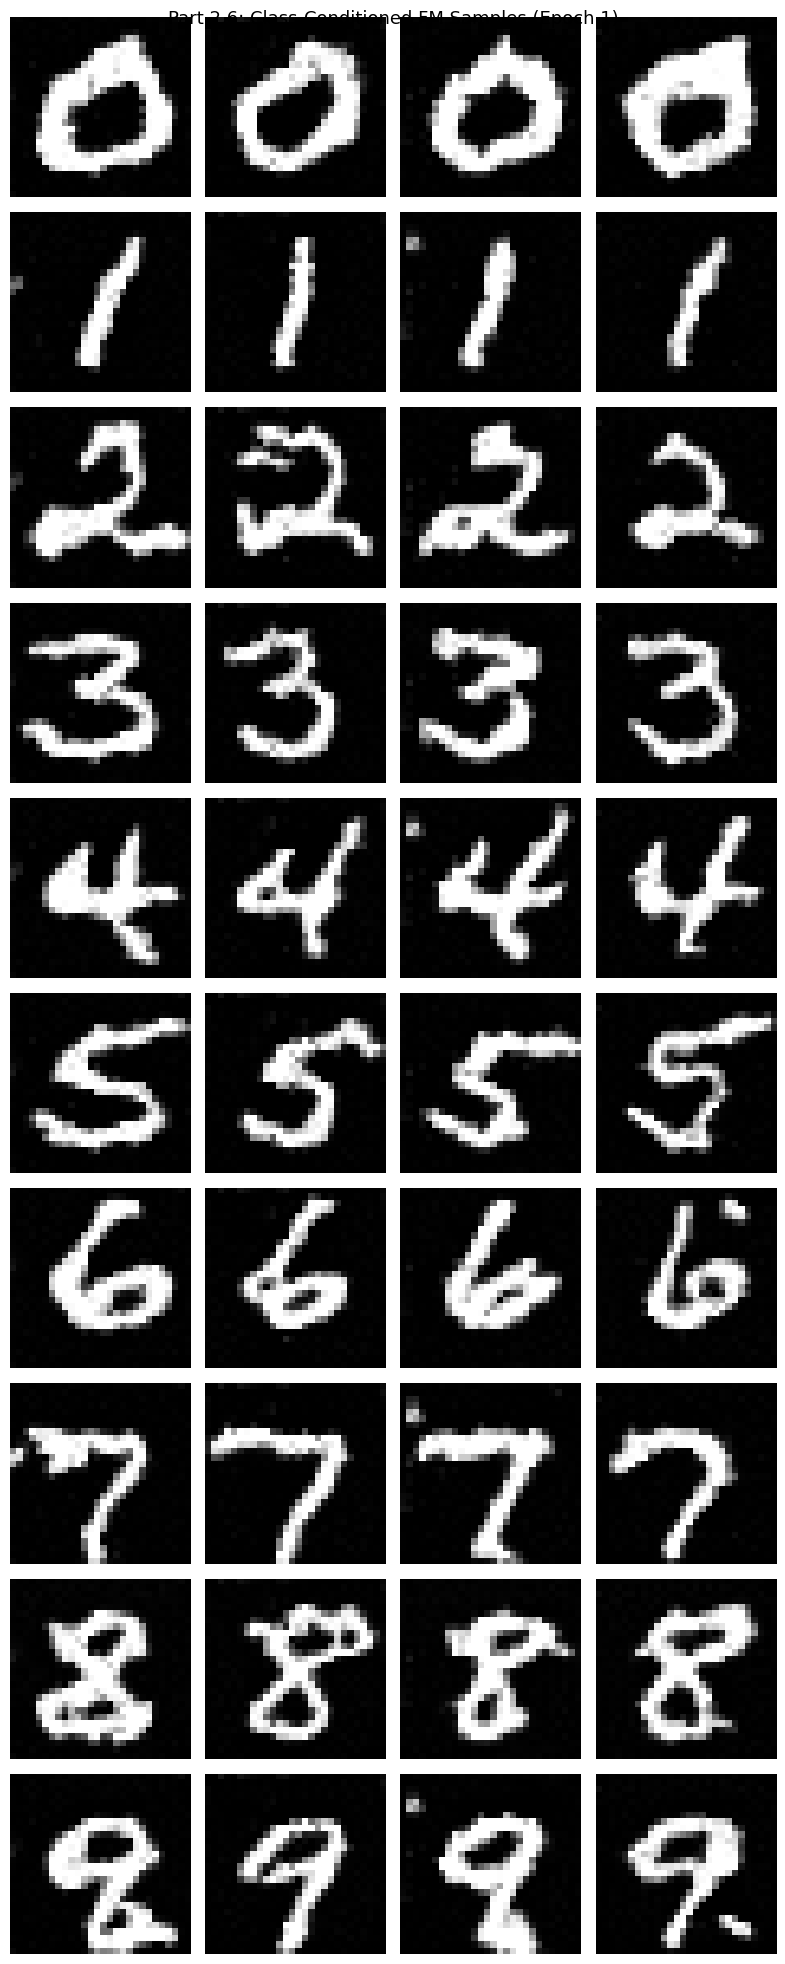

Saved cc_samples/part2_cc_epoch1.png


CC Epoch 5/10: 100%|██████████| 938/938 [00:59<00:00, 15.83it/s]


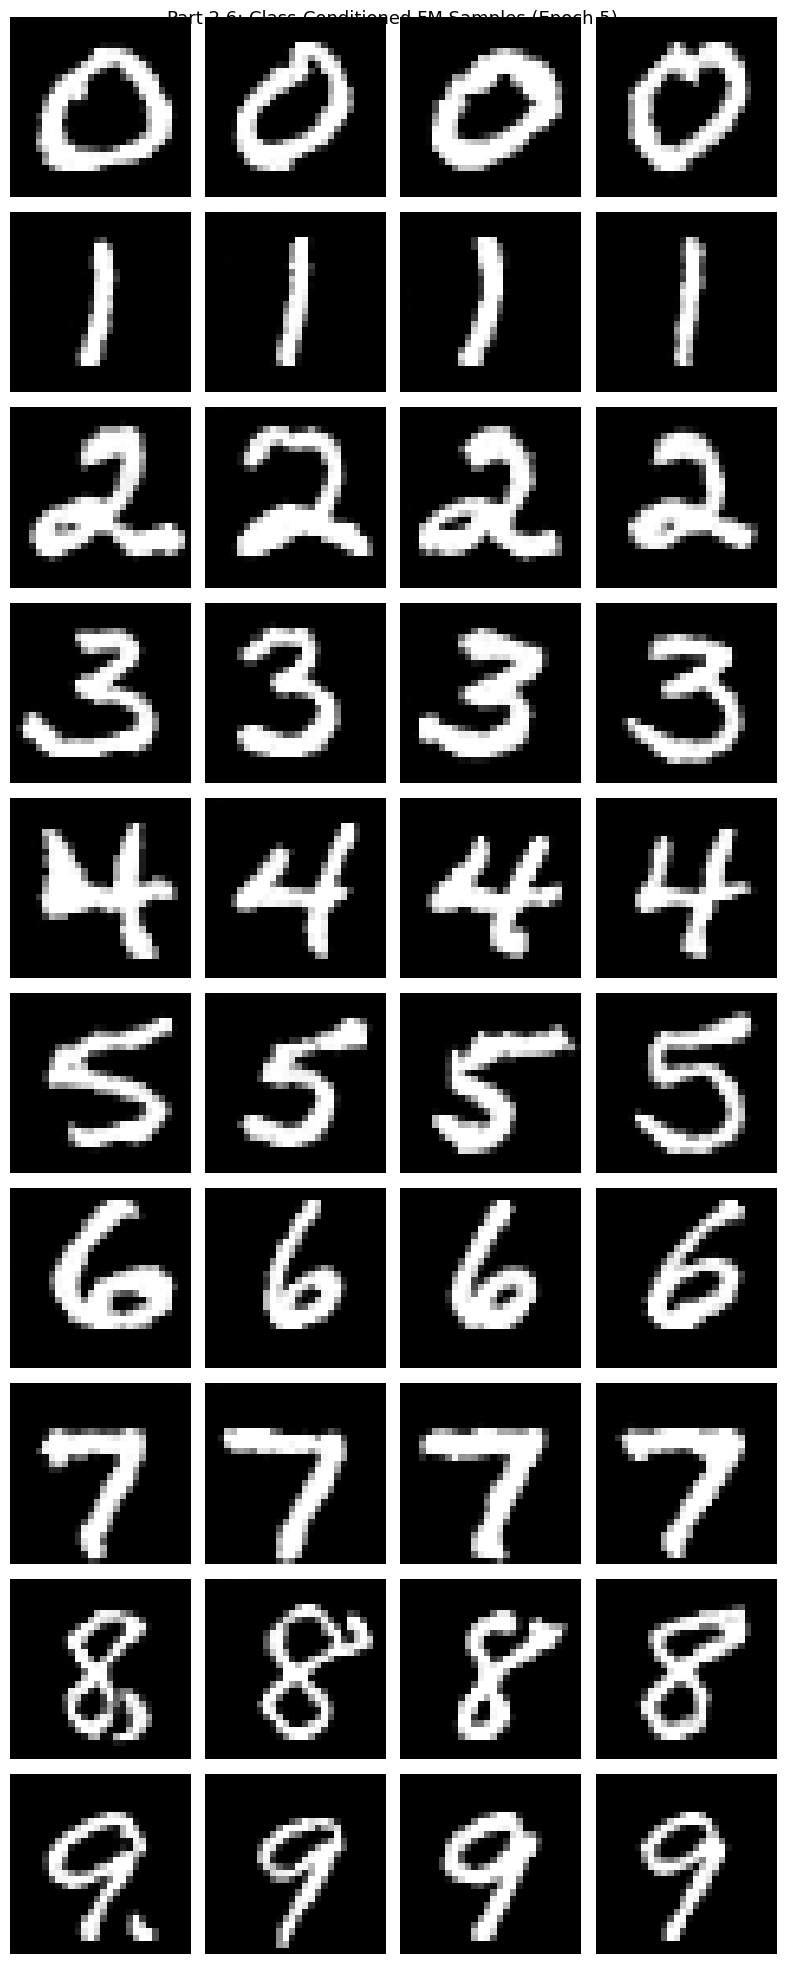

Saved cc_samples/part2_cc_epoch5.png


CC Epoch 10/10: 100%|██████████| 938/938 [00:59<00:00, 15.82it/s]


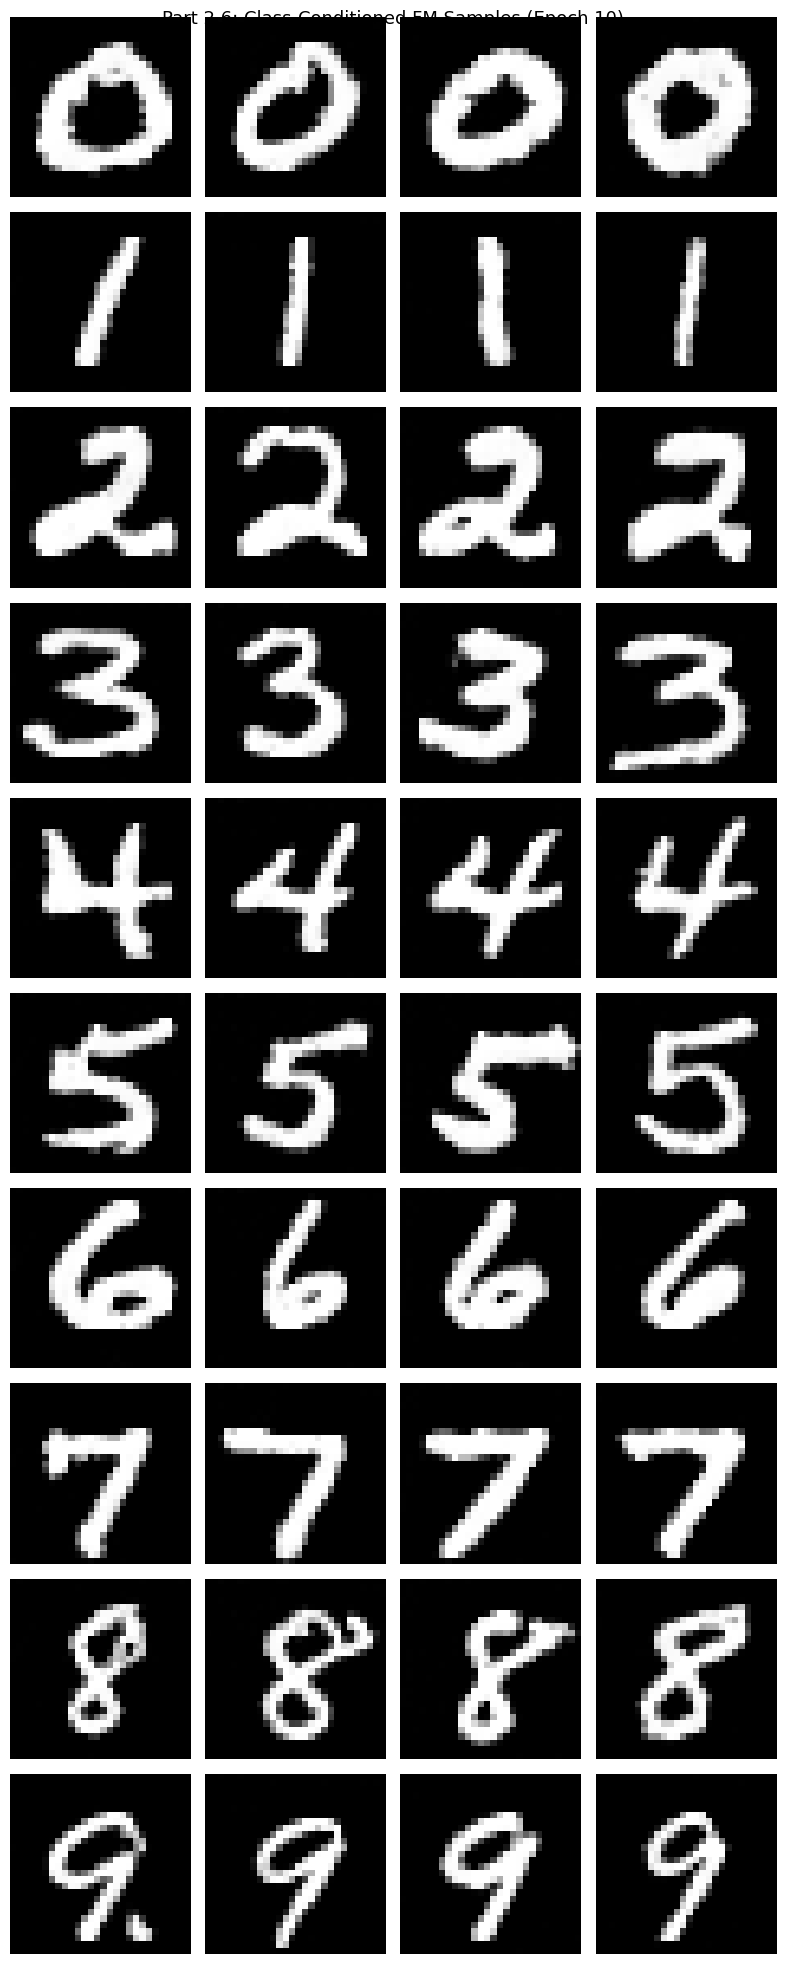

Saved cc_samples/part2_cc_epoch10.png


In [28]:
cc_train_losses = []
cc_sample_epochs = [1, 5, 10]
os.makedirs('cc_samples', exist_ok=True)

for epoch in range(1, cc_num_epochs + 1):
    cc_unet.train()
    for images, labels in tqdm(cc_train_loader, desc=f'CC Epoch {epoch}/{cc_num_epochs}'):
        images = images.to(device)
        labels = labels.to(device)

        loss = class_fm_forward(cc_unet, images, labels, cc_p_uncond, cc_num_ts)
        cc_optimizer.zero_grad()
        loss.backward()
        cc_optimizer.step()

        cc_train_losses.append(loss.item())

    cc_scheduler.step()

    if epoch in cc_sample_epochs:
        # Generate 4 of each digit = 40 images total
        all_samples = []
        for digit in range(10):
            c_batch = torch.full((4,), digit, dtype=torch.long, device=device)
            samples, _ = class_fm_sample(
                cc_unet, c_batch, (28, 28), num_ts=50, guidance_scale=5.0, seed=42
            )
            all_samples.append(samples.cpu())
        all_samples = torch.cat(all_samples, dim=0)  # (40, 1, 28, 28)

        fig, axes = plt.subplots(10, 4, figsize=(8, 20))
        for digit in range(10):
            for k in range(4):
                axes[digit, k].imshow(
                    all_samples[digit * 4 + k].squeeze().clamp(0, 1), cmap='gray'
                )
                axes[digit, k].axis('off')
            axes[digit, 0].set_ylabel(f'Digit {digit}', fontsize=10)

        plt.suptitle(f'Part 2.6: Class-Conditioned FM Samples (Epoch {epoch})', fontsize=13)
        plt.tight_layout()
        path = f'cc_samples/part2_cc_epoch{epoch}.png'
        plt.savefig(path, dpi=100, bbox_inches='tight')
        plt.show()
        print(f'Saved {path}')

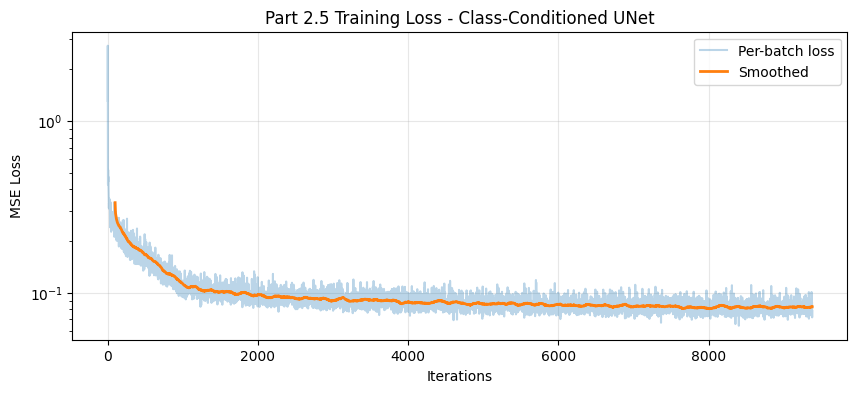

In [29]:
# Training curve
plt.figure(figsize=(10, 4))
plt.plot(cc_train_losses, alpha=0.3, label='Per-batch loss')
w = 100
s = np.convolve(cc_train_losses, np.ones(w)/w, mode='valid')
plt.plot(range(w-1, len(cc_train_losses)), s, label='Smoothed', linewidth=2)
plt.xlabel('Iterations')
plt.ylabel('MSE Loss')
plt.title('Part 2.5 Training Loss - Class-Conditioned UNet')
plt.legend()
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.savefig('part2_cc_training_curve.png', dpi=100, bbox_inches='tight')
plt.show()

# Part 2.6: Sampling from the Class-conditioned UNet


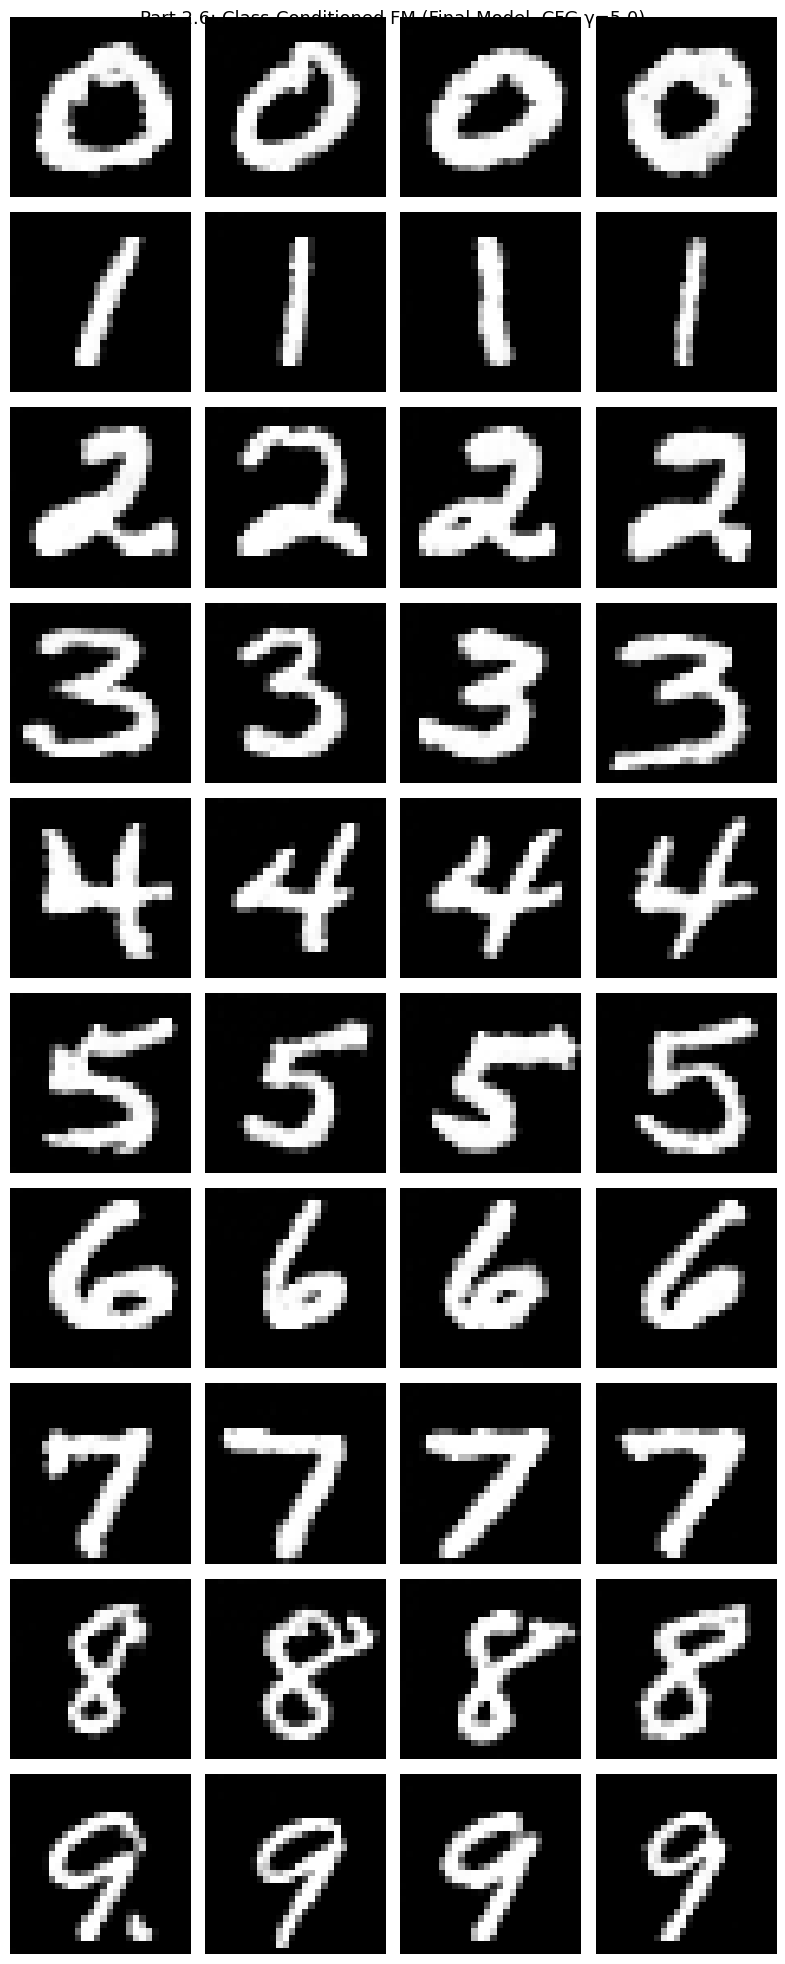

Saved cc_samples/part2_cc_final.png

Note: epoch-specific samples (epochs 1, 5, 10) were saved during training
as cc_samples/part2_cc_epoch1.png, cc_samples/part2_cc_epoch5.png, cc_samples/part2_cc_epoch10.png


In [32]:
# Part 2.6: Sampling from the Class-conditioned UNet with CFG (gamma=5.0)
# Generate 4 instances of each digit (0-9) = 40 images total

os.makedirs('cc_samples', exist_ok=True)

all_samples_final = []
for digit in range(10):
    c_batch = torch.full((4,), digit, dtype=torch.long, device=device)
    samples, _ = class_fm_sample(
        cc_unet, c_batch, (28, 28), num_ts=cc_num_ts, guidance_scale=5.0, seed=42
    )
    all_samples_final.append(samples.cpu())

all_samples_final = torch.cat(all_samples_final, dim=0)  # (40, 1, 28, 28)

fig, axes = plt.subplots(10, 4, figsize=(8, 20))
for digit in range(10):
    for k in range(4):
        axes[digit, k].imshow(
            all_samples_final[digit * 4 + k].squeeze().clamp(0, 1).numpy(),
            cmap='gray'
        )
        axes[digit, k].axis('off')
    axes[digit, 0].set_ylabel(f'Digit {digit}', fontsize=10)

plt.suptitle('Part 2.6: Class-Conditioned FM (Final Model, CFG γ=5.0)', fontsize=13)
plt.tight_layout()
plt.savefig('cc_samples/part2_cc_final.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved cc_samples/part2_cc_final.png')
print('\nNote: epoch-specific samples (epochs 1, 5, 10) were saved during training')
print('as cc_samples/part2_cc_epoch1.png, cc_samples/part2_cc_epoch5.png,'
      ' cc_samples/part2_cc_epoch10.png')


## Bells & Whistles: Removing the LR Scheduler

To compensate for removing the exponential LR decay, we use a lower initial learning rate (1e-3 instead of 1e-2) and train with the Adam optimizer's built-in adaptive learning rates. This avoids the instability of a high initial LR while still converging well.

No-Sched Epoch 10/10: 100%|██████████| 938/938 [00:59<00:00, 15.82it/s]


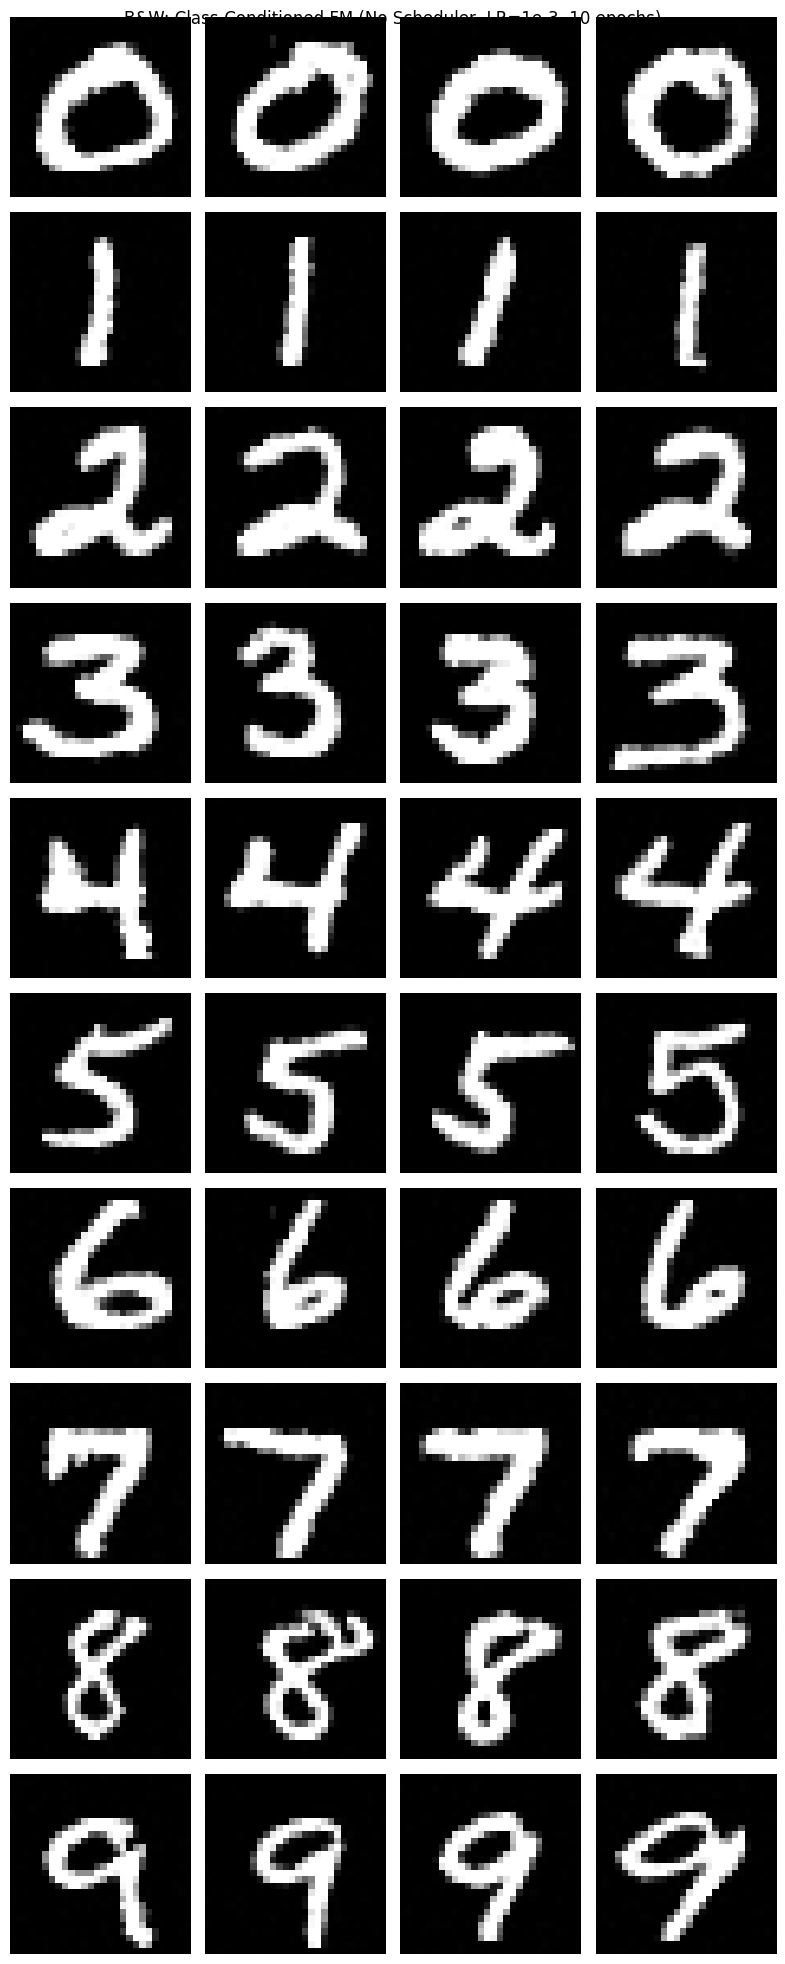


Without the LR scheduler, we use a lower base learning rate (1e-3 vs 1e-2).
The exponential LR scheduler effectively prevents the optimizer from making
large updates late in training. Without it, starting with a smaller lr achieves
a similar effect — stable training from the start without oscillations.



In [30]:
# Train without LR scheduler (compensate with lower LR)
cc_unet_no_sched = ClassConditionalUNet(
    in_channels=1, num_classes=10, num_hiddens=64
).to(device)
cc_optimizer_no_sched = torch.optim.Adam(cc_unet_no_sched.parameters(), lr=1e-3)  # lower LR

cc_train_losses_no_sched = []
for epoch in range(1, cc_num_epochs + 1):
    cc_unet_no_sched.train()
    for images, labels in tqdm(cc_train_loader, desc=f'No-Sched Epoch {epoch}/{cc_num_epochs}'):
        images = images.to(device)
        labels = labels.to(device)

        loss = class_fm_forward(cc_unet_no_sched, images, labels, cc_p_uncond, cc_num_ts)
        cc_optimizer_no_sched.zero_grad()
        loss.backward()
        cc_optimizer_no_sched.step()

        cc_train_losses_no_sched.append(loss.item())

# Sample and display results
all_samples_ns = []
for digit in range(10):
    c_batch = torch.full((4,), digit, dtype=torch.long, device=device)
    samples, _ = class_fm_sample(
        cc_unet_no_sched, c_batch, (28, 28), num_ts=50, guidance_scale=5.0, seed=42
    )
    all_samples_ns.append(samples.cpu())
all_samples_ns = torch.cat(all_samples_ns, dim=0)

fig, axes = plt.subplots(10, 4, figsize=(8, 20))
for digit in range(10):
    for k in range(4):
        axes[digit, k].imshow(
            all_samples_ns[digit * 4 + k].squeeze().clamp(0, 1), cmap='gray'
        )
        axes[digit, k].axis('off')
    axes[digit, 0].set_ylabel(f'Digit {digit}', fontsize=10)

plt.suptitle('B&W: Class-Conditioned FM (No Scheduler, LR=1e-3, 10 epochs)', fontsize=12)
plt.tight_layout()
plt.savefig('part2_cc_no_scheduler.png', dpi=100, bbox_inches='tight')
plt.show()

print("""
Without the LR scheduler, we use a lower base learning rate (1e-3 vs 1e-2).
The exponential LR scheduler effectively prevents the optimizer from making
large updates late in training. Without it, starting with a smaller lr achieves
a similar effect — stable training from the start without oscillations.
""")

In [33]:
# In Part B, images are already saved to disk as .png files
# Just zip those folders up directly
import shutil
from google.colab import files

shutil.make_archive('/content/hw5b_outputs', 'zip', 'fm_samples')
files.download('/content/hw5b_outputs.zip')

# also download cc_samples
shutil.make_archive('/content/hw5b_cc', 'zip', 'cc_samples')
files.download('/content/hw5b_cc.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>